In [1]:
import numpy as np

In [2]:
array = np.array([1,2,3])
print(array*np.pi)

[3.14159265 6.28318531 9.42477796]


In [4]:
array>2

array([False, False,  True])

K-MEANS FROM SCRATCH USING NUMPY


In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import make_blobs

x,y = make_blobs(n_samples = 1000 , centers = 5  , n_features = 2)

In [3]:
print(x)
print(y)
print(len(x))
print(len(y))

[[ 8.735964   -1.61401661]
 [ 9.54175003 -0.95477485]
 [ 7.63607103  7.90305493]
 ...
 [ 6.70375065 -1.03294781]
 [ 5.62556388  8.53505969]
 [ 7.50067391  7.52762335]]
[0 0 4 2 0 4 0 3 3 4 0 3 3 1 0 1 3 1 4 4 3 2 2 3 2 1 3 2 4 0 2 2 4 0 4 3 1
 1 4 1 4 1 2 2 0 4 2 1 3 0 0 3 4 4 2 1 3 2 1 4 1 4 0 2 1 0 4 3 1 3 3 3 4 4
 3 4 0 2 4 3 3 4 1 4 3 3 0 4 1 1 1 0 0 1 3 2 1 0 1 3 1 2 3 3 4 0 0 0 1 4 1
 1 2 4 2 1 1 4 1 3 3 0 4 0 3 0 4 3 1 2 1 1 2 3 3 2 1 1 4 2 3 3 4 1 1 2 1 0
 4 1 3 3 3 4 0 3 2 4 3 1 3 1 1 1 1 2 2 4 2 3 1 4 3 2 0 2 0 4 3 4 3 4 3 3 0
 2 1 2 3 2 2 0 0 1 1 4 3 2 1 0 0 1 2 2 0 3 4 0 3 3 0 0 0 0 4 4 4 2 3 1 1 1
 4 1 3 0 3 4 2 2 4 0 2 3 4 3 4 2 3 3 4 2 3 4 0 1 1 2 3 3 0 0 0 1 1 0 3 4 4
 0 2 4 2 4 2 1 4 0 0 2 4 4 4 3 4 1 4 4 1 1 3 3 1 3 0 4 4 4 4 0 4 3 1 0 0 2
 1 0 2 1 0 4 2 4 1 4 2 0 1 1 4 4 0 1 4 2 0 3 3 4 3 1 1 0 4 0 0 2 1 3 4 4 2
 2 0 4 4 2 4 1 1 3 4 4 3 4 3 4 0 3 2 3 0 4 2 3 2 2 1 2 2 3 3 3 0 1 2 0 2 2
 4 4 4 4 4 0 3 3 2 4 1 2 0 2 1 4 1 3 2 3 3 1 3 0 4 4 2 0 3 0 3 1 1 0 3 0 0
 4 0 0 

In [4]:
def dist(a,b):
    d = np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)
    return d


In [5]:
def cen_mean(x):
    return np.mean(x,axis=0)

In [92]:
class k_means:
    def __init__(self,x,y):
        self.x = x
        self.y = y
         

    def fit(self,x_train,runs):
        cen =[]
        
        c = np.random.choice(800,5,replace=False)
        cen.append(x_train[c])
        cen = cen[0]
        print(f'cen = ',cen)
        
        for i in range(0,runs):
            distances = []
            y_pred = []
            
            for j in range(0,800):
                d = [dist(x_train[j],cen[0]),dist(x_train[j],cen[1]),dist(x_train[j],cen[2]),dist(x_train[j],cen[3]),dist(x_train[j],cen[4])]
                distances.append(d)
                y_pred.append(np.argmin(distances[-1]))
                
                    
            y_pred = np.array(y_pred)
            for m in range(5):
                cluster = x_train[y_pred == m]

                if len(cluster) == 0:
                    continue

                cen[m] = np.mean(cluster, axis=0)
        for q in range(0,5):
            classes = x_train[y_pred == q]
            print(f"Cluster {q}: {len(classes)} points")

        return cen,y_pred
        
    
    def pred(self,x_test,cen):

        y_pred = []
        distances = []
        for j in range(len(x_test)):
            d = [dist(x_test[j],cen[0]),dist(x_test[j],cen[1]),dist(x_test[j],cen[2]),dist(x_test[j],cen[3]),dist(x_test[j],cen[4])]
            distances.append(d)
            y_pred.append(np.argmin(distances[-1]))
            

        return y_pred
        
            

In [93]:
from sklearn.model_selection import train_test_split 

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
km = k_means(x,y)
cen, y_pred = km.fit(x_train, 1000)
print(cen , y_pred)


cen =  [[ 8.18011051  0.08987916]
 [-6.83502104  2.49945863]
 [-8.85631767  3.75736138]
 [ 8.04461611 -3.40312653]
 [ 7.94861338  6.75028795]]
Cluster 0: 88 points
Cluster 1: 321 points
Cluster 2: 153 points
Cluster 3: 71 points
Cluster 4: 167 points
[[ 8.16184584 -0.9201597 ]
 [-7.45450427  1.79332379]
 [-3.37113101  9.94512201]
 [ 9.67747478 -1.83689505]
 [ 7.24680402  7.26336606]] [3 2 4 0 3 1 1 4 0 1 0 2 4 1 1 4 2 2 1 1 4 4 2 3 1 4 0 1 1 1 2 1 3 3 0 1 0
 4 0 1 1 0 4 1 1 4 4 1 2 4 1 1 4 0 2 0 4 3 1 4 4 1 0 4 1 1 0 1 3 1 2 1 4 0
 1 4 2 3 4 4 1 1 2 4 0 4 1 2 4 3 0 1 0 4 2 2 3 1 2 2 0 4 1 4 1 1 3 4 4 1 0
 2 0 2 3 0 1 3 2 0 2 4 1 4 4 4 4 3 4 2 4 4 1 3 0 3 2 1 1 1 1 2 2 0 4 4 2 4
 1 1 4 4 2 2 2 1 3 1 3 1 1 1 1 1 1 4 1 1 1 1 2 4 2 1 0 1 2 4 2 1 2 1 4 4 1
 4 3 1 1 1 1 1 2 1 1 2 0 1 1 0 1 2 2 1 1 2 1 4 2 0 4 1 3 1 3 1 1 4 1 2 4 1
 3 2 1 0 4 4 4 4 4 1 1 2 1 2 2 1 1 1 1 4 2 3 3 1 1 3 1 0 3 1 3 1 2 4 2 1 3
 1 2 4 1 2 2 4 1 2 1 1 3 3 1 1 4 2 2 0 2 1 0 2 2 1 1 1 1 2 4 2 4 1 0 1 0 2
 2 3 4 0 1 4 

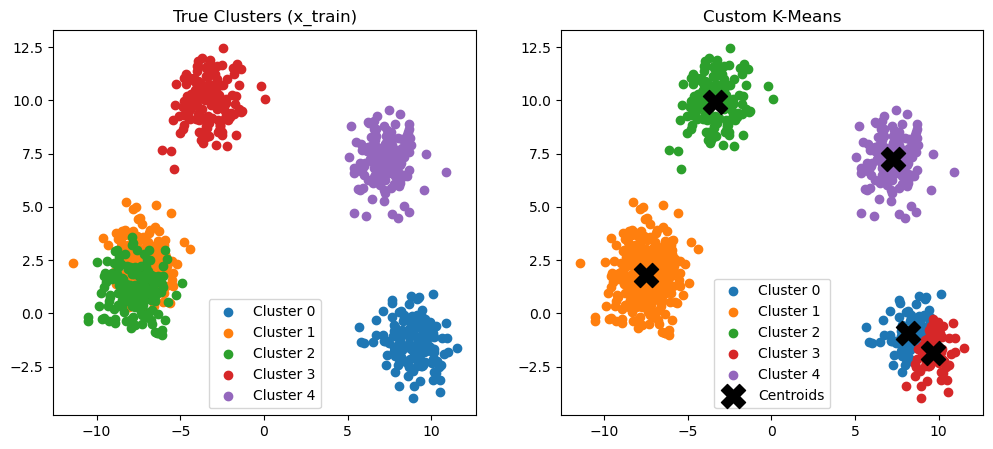

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Actual training labels
for c in np.unique(y_train):
    pts = x_train[y_train == c]
    ax[0].scatter(pts[:,0], pts[:,1], label=f'Cluster {c}')

ax[0].set_title("True Clusters (x_train)")
ax[0].legend()

# Your K-Means result
for c in range(5):
    pts = x_train[y_pred == c]
    ax[1].scatter(pts[:,0], pts[:,1], label=f'Cluster {c}')

ax[1].scatter(
    cen[:,0],
    cen[:,1],
    marker='X',
    s=300,
    c='black',
    label='Centroids'
)

ax[1].set_title("Custom K-Means")
ax[1].legend()

plt.show()